In [1]:
pip install --quiet -U langgraph


[notice] A new release of pip is available: 24.1.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
import os, getpass
def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}:")

_set_env("OPENAI_API_KEY")


In [11]:
_set_env("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACKIN_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "langgraph_aka"

In [12]:
from typing import TypedDict

class State(TypedDict):
    graph_state: str

### NODEs

In [13]:
def node_1(state):
    print("---Node 1---")
    return {"graph_state": state['graph_state'] + " I am"}

def node_2(state):
    print("---Node 2---")
    return {"graph_state": state['graph_state'] + " playing Intercessors"}

def node_3(state):
    print("---Node 3---")
    return {"graph_state": state['graph_state'] + " playing Plague Marines"}

### Edges

In [14]:
import random

from typing import Literal

def decide_mood(state) -> Literal["node_two", "node_three"]:

    
    user_input = state['graph_state']

    
    if random.random() < 0.5:

        return "node_two"

    else:
        return "node_three"
    

### Construction

In [15]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END


builder = StateGraph(State)
builder.add_node("node_one", node_1)
builder.add_node("node_two", node_2)
builder.add_node("node_three", node_3)

builder.add_edge(START, "node_one")
builder.add_conditional_edges("node_one", decide_mood)
builder.add_edge("node_two", END)
builder.add_edge("node_three", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

ReadTimeout: HTTPSConnectionPool(host='mermaid.ink', port=443): Read timed out. (read timeout=10)

In [ ]:
graph.invoke({"graph_state" : "Hi, this is Krystof"})

### Chains

In [16]:
pip install langchain_openai langchain_core langgraph


[notice] A new release of pip is available: 24.1.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [17]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=f"So you said you were researching aquatic animals?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Krystof"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see sharks in Europe.", name="krystof"))


#print(messages)

for m in messages:
    
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching aquatic animals?
================================ Human Message =================================
Name: Krystof

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: krystof

I want to learn about the best place to see sharks in Europe.


In [18]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o")
result = llm.invoke(messages)

In [19]:
type(result)

langchain_core.messages.ai.AIMessage

In [20]:
result

AIMessage(content='If you’re interested in seeing sharks in Europe, there are a few excellent spots that are popular for shark sightings and diving:\n\n1. **Azores, Portugal**: The waters around the Azores are known for their rich marine biodiversity, including sightings of blue sharks and mako sharks, particularly during the summer months.\n\n2. **Silfra, Iceland**: Although not typical for shark sightings, Iceland offers unique diving experiences. For actual shark watching, head to other regions in Europe.\n\n3. **Isle of Man, UK**: The Isle of Man is known for basking sharks, especially during the summer months. These gentle giants are often seen near the surface, feeding on plankton.\n\n4. **Mediterranean Sea**: While sightings here are less common compared to other destinations, there have been occasional reports of various shark species, including blue sharks and even the rare great white shark in this region.\n\n5. **Scotland**: Areas on the west coast of Scotland, such as aroun

In [21]:
result.response_metadata

{'token_usage': {'completion_tokens': 305,
  'prompt_tokens': 69,
  'total_tokens': 374,
  'completion_tokens_details': {'accepted_prediction_tokens': 0,
   'audio_tokens': 0,
   'reasoning_tokens': 0,
   'rejected_prediction_tokens': 0},
  'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}},
 'model_name': 'gpt-4o-2024-08-06',
 'system_fingerprint': 'fp_eb9dce56a8',
 'finish_reason': 'stop',
 'logprobs': None}

In [22]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
    a: first int
    b: second int
    """
    return a * b

llm_with_tools = llm.bind_tools([multiply])

In [23]:
tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by 3", name="Krystof")])

In [24]:
tool_call.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'call_KlnrCJ1DenRxWLkaqI7Kz9i2',
  'type': 'tool_call'}]

In [25]:
tool_call

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_KlnrCJ1DenRxWLkaqI7Kz9i2', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 64, 'total_tokens': 82, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_eb9dce56a8', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-b8f1e44a-dc36-408c-a7c4-1f30e0a6d1b7-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'call_KlnrCJ1DenRxWLkaqI7Kz9i2', 'type': 'tool_call'}], usage_metadata={'input_tokens': 64, 'output_tokens': 18, 'total_tokens': 82, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [26]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages: list[AnyMessage]

In [27]:
from typing import Annotated
from langgraph.graph.message import add_messages

class MessagesState(MessagesState):
    pass

In [28]:
initial_message = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                   HumanMessage(content="I'm looking for information on marine biology.", name="Krystof")
                  ]

new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

add_messages(initial_message, new_message)


[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='10743c39-0bfc-4524-8f35-9d5f23a7ebe7'),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Krystof', id='c183b08d-13c2-4128-82d2-5e256a6e6c48'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='9b4b09d0-95ce-457b-b621-848217172bc5')]

In [29]:
from langgraph.graph import MessagesState

class State(MessagesState):
    pass

In [30]:
initial_message = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                   HumanMessage(content="I'm looking for information on marine biology.", name="Krystof")
                  ]

new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

add_messages(initial_message, new_message)


[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='59eb4de8-7441-44f1-be71-12f3bc6fc9b9'),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Krystof', id='045e5586-dbcc-4c31-a1ab-53dc3f508092'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='391c45d4-177a-4e4b-ad25-d79feedd1f30')]

In [31]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

class MessageState(MessagesState):
    pass

def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

ReadTimeout: HTTPSConnectionPool(host='mermaid.ink', port=443): Read timed out. (read timeout=10)

In [32]:
message = graph.invoke({"messages": HumanMessage(content="Hello!")})
for m in message["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Hello! How can I assist you today?


In [33]:
messages = graph.invoke({"messages": HumanMessage(content="Multiply 2 and 3!")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3!
================================== Ai Message ==================================
Tool Calls:
  multiply (call_R9Zt9tDPKfU0wHg10ZqxYnvw)
 Call ID: call_R9Zt9tDPKfU0wHg10ZqxYnvw
  Args:
    a: 2
    b: 3


In [34]:
from langchain_openai import ChatOpenAI

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

llm = ChatOpenAI(model="gpt-4o")
llm_with_tools = llm.bind_tools([multiply])

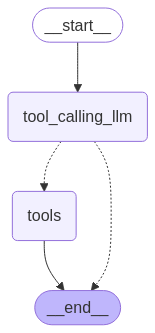

In [35]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode([multiply]))
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
from langchain_core.messages import HumanMessage
messages = [HumanMessage(content="Hello, what is 16 multiplied by 16? .")]
messages = graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello, what is 16 multiplied by 16? .
================================== Ai Message ==================================
Tool Calls:
  multiply (call_iAH9ZpKfBH9d1V6Os0hyEGbX)
 Call ID: call_iAH9ZpKfBH9d1V6Os0hyEGbX
  Args:
    a: 16
    b: 16
================================= Tool Message =================================
Name: multiply

256


### Agent


In [37]:
from langchain_openai import ChatOpenAI

def multiply(a: int, b: int) -> int:
    """Multiply a and b

    Args:
        a: first int
        b: second int
    """
    return a * b

def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]
llm = ChatOpenAI(model="gpt-4o")
llm_with_tools = llm.bind_tools(tools)

In [38]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

sys_msg = SystemMessage(content="You are a helpful assistant tasked with performaing arithmetic on a set of inputs.")

def assistant(state: MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

In [39]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

builder = StateGraph(MessagesState)

builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition,)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

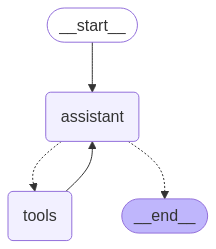

In [40]:
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [44]:
messages = [HumanMessage(content="add 3 and 4")]
messages = react_graph.invoke({"messages": messages})


In [45]:
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

add 3 and 4
================================== Ai Message ==================================
Tool Calls:
  add (call_vylKdiFOpsb0ZQOYvWC1QMRK)
 Call ID: call_vylKdiFOpsb0ZQOYvWC1QMRK
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

The result of adding 3 and 4 is 7.


In [48]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
react_graph_memory = builder.compile(checkpointer=memory)

In [50]:
config = {"configurable": {"thread_id": "1"}}

messages = [HumanMessage(content="Add 3 and 4.")]

messages = react_graph_memory.invoke({"messages": messages}, config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_CBfMtGd01NH26kd6Sst8ZZFl)
 Call ID: call_CBfMtGd01NH26kd6Sst8ZZFl
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

The sum of 3 and 4 is 7.


In [54]:
messages = [HumanMessage(content="could you add 1 and then multiply it by 11?")]
messages = react_graph_memory.invoke({"messages": messages}, config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_CBfMtGd01NH26kd6Sst8ZZFl)
 Call ID: call_CBfMtGd01NH26kd6Sst8ZZFl
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

The sum of 3 and 4 is 7.
================================ Human Message =================================

add 3 to thata
================================== Ai Message ==================================

It seems there was a misunderstanding. When you say "thata," are you referring to the previous result? If so, it is 7. Would you like me to add 3 to 7?
================================ Human Message =================================

add 3 to that
================================== Ai Message ==================================

In [ ]:
from langchain import ChatO